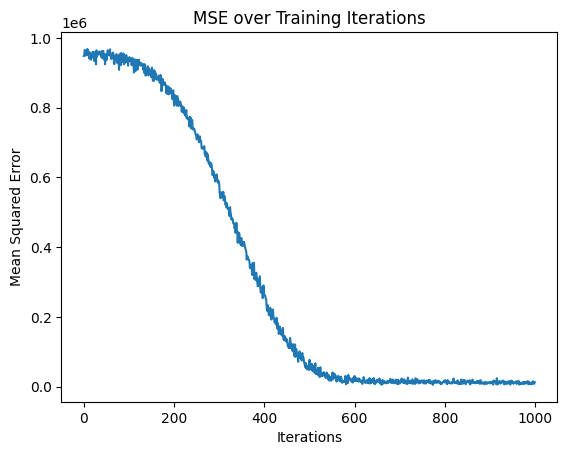

In [ ]:
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# Sub-Question 1: Random Data Generator
def generate_random_set(Nk_min=10, Nk_max=100, value_min=0, value_max=999):
    Nk = random.randint(Nk_min, Nk_max)  # Sample Nk
    random_set = np.random.choice(range(value_min, value_max + 1), size=Nk, replace=False)  # Generate unique integers
    return random_set

# Sub-Question 2: Define a Set Neural Network
def set_neural_network():
    # Since we are dealing with sets which are permutation-invariant, the architecture should reflect this property.
    inputs = layers.Input(shape=(None,))
    x = layers.Embedding(input_dim=1000, output_dim=64)(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.GlobalMaxPool1D()(x)  # This layer ensures permutation invariance
    outputs = layers.Dense(1)(x)  # The maximum value of the set is a single scalar

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Sub-Question 4: Train Model and Report MSE with Padding
def train_model(model, iterations=1000, batch_size=32, Nk_min=10, Nk_max=100, value_min=0, value_max=999):
    mse_history = []
    for i in range(iterations):
        # Generate a batch of random sets
        batch_data = [generate_random_set(Nk_min, Nk_max, value_min, value_max) for _ in range(batch_size)]
        # Pad sequences for consistent input size
        batch_data_padded = pad_sequences(batch_data, padding='post', value=0)
        # Find the max value for each set
        batch_labels = np.array([np.max(data_set) for data_set in batch_data])
        # Train the model on this batch
        history = model.train_on_batch(batch_data_padded, batch_labels)
        mse_history.append(history)
    return mse_history


# Initialize the set neural network
model = set_neural_network()

# Train the model and get the MSE history
mse_history = train_model(model, iterations=1000, batch_size=32)  # Training iterations set to 1000 for example

# Report MSE as a function of training iterations
plt.plot(mse_history)
plt.title('MSE over Training Iterations')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error')
plt.show()

For sub-question 3:

The design choices made ensure that the neural network is permutation-invariant with respect to the input set. Permutation invariance means that the output of the model (in this case, the maximum value of the set) does not change regardless of the order of the elements in the input set.

1. **Embedding Layer**: The embedding layer helps to project the integers into a higher-dimensional space, providing a richer representation for each number. This does not affect the permutation invariance since each number is embedded independently.

2. **Dense Layer**: The dense layer applied after embedding is shared across all elements, treating each one equally and independently, maintaining permutation invariance.

3. **Global Max Pooling**: The `GlobalMaxPool1D` operation is the critical component that ensures the model's output is invariant to the permutation of the set. It takes the maximum over the set of outputs from the previous dense layer, which by definition is the same regardless of element order.

4. **Padding**: Padding the input sequences with zeros to ensure uniform length does not impact the model's invariance property. The padding simply allows for batch processing of the inputs. Since the maximum value of a set is not affected by the addition of zeros (given the range of the set elements), the padding does not introduce any order dependency.

5. **Final Dense Layer**: The final dense layer outputs the maximum value prediction. Since all previous layers are designed to maintain invariance, this layer outputs the desired value, respecting the set's unordered nature.

In summary, the neural network's architecture reflects the required geometric principles by ensuring that the computation of the maximum value is invariant to the order of the input set elements, adhering to the permutation invariance property.